In [16]:
import os
import sys
import time
import copy

import numpy as np
import math
import random
import matplotlib.pyplot as plt

import functools
import argparse

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils

import pickle

import datasets, models
import importlib
importlib.reload(models)
import init, measures
importlib.reload(init)
importlib.reload(models)

<module 'models' from '/Users/tigraneponsin/Projects/SAE-on-RHM/models/__init__.py'>

In [54]:
from dataclasses import dataclass
@dataclass
class config:

    device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

    dataset = 'rhm'
    mode = 'class'
    num_features = 3
    num_classes = 3
    num_synonyms = 3
    tuple_size = 2
    num_layers = 3
    seed_rules = 12345678
    num_tokens = 8

    train_size = 2**15
    batch_size = 128
    accumulation = 1
    test_size = 2**15
    seed_sample = 12345678

    input_format = 'long'
    whitening = False

    model = 'transformer_class'
    embedding_dim = 512
    num_heads = 8
    ffwd_size = 4
    depth = 3
    num_classes = 3
    dropout = 0.0

    optim = 'adam'
    lr = 1e-3
    momentum = 0.0
    scheduler = None
    max_epochs = 10000

    print_freq = 32768
    save_freq = 2
    measure_train = False
    loss_threshold = 1e-3

config.num_data = config.num_classes*config.num_synonyms**((config.tuple_size**config.num_layers-1)//(config.tuple_size-1))
config.input_size = config.tuple_size**config.num_layers
config.num_batches = config.train_size//config.batch_size
config.max_iters = config.max_epochs*config.num_batches

print(f'{config.train_size} training data (total {config.num_data})')
print(config.device)
print(f"Training for {config.max_iters} steps")

32768 training data (total 6561)
mps
Training for 2560000 steps


In [55]:
print(f'{config.train_size} training data (total {config.num_data})')
print(config.device)
print(f"Training for {config.max_iters} steps")


32768 training data (total 6561)
mps
Training for 2560000 steps


In [56]:
# reinitialise dataset seeds for multiple runs
config.seed_rules = random.randint(10000000,99999999)
config.seed_sample = random.randint(10000000,99999999)
print(config.seed_rules, config.seed_sample)

70918778 76513784


## Initialise dataset

In [57]:
if config.dataset=='rhm':

    rhm = datasets.RHM(
        v=config.num_features,
        n=config.num_classes,
        m=config.num_synonyms,
        s=config.tuple_size,
        L=config.num_layers,
        seed_rules=config.seed_rules,
        seed_samples=config.seed_sample,
        num_data=config.train_size+config.test_size,
        probs=None,
        transform=None
    )
    inputs = rhm.trees[config.num_layers]
    targets = rhm.trees[0]

print(inputs.size())
print(targets.size())
train_loader, test_loader = init.init_data(inputs, targets, config)
# train_loader, test_loader = init.init_data(inputs, targets, config)
# for batch_idx, (x, y) in enumerate(train_loader):
#     print(x.size(), y.size())

torch.Size([65536, 8])
torch.Size([65536])


## Initialise Model

In [58]:
config.num_tokens = config.tuple_size**config.num_layers
config.seed_model = random.randint(10000000,99999999)

model = init.init_model(config)
model0 = copy.deepcopy( model)

criterion, optimizer, scheduler = init.init_training( model, config)

# parameters: 9452547


## Train until convergence of the training loss

In [59]:
%%time
dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)
print(dynamics[0])

print_ckpts, save_ckpts = init.init_loglinckpt( config.print_freq, config.max_iters, freq=config.save_freq)
print_ckpt = next(print_ckpts)
save_ckpt = next(save_ckpts)

step = 0
config.outname = 'test'
print(config.outname)

{'t': 0, 'testloss': 1.1181314662098885, 'testacc': 0.328643798828125}
test
CPU times: user 544 ms, sys: 682 ms, total: 1.23 s
Wall time: 6.51 s


In [ ]:
for epoch in range(config.max_epochs):

    model.train()
    optimizer.zero_grad()
    running_loss = 0.

    for batch_idx, (inputs, targets) in enumerate(train_loader):

        outputs = model(inputs.to(config.device))
        loss = criterion(outputs.view(-1, outputs.size(-1)), targets.to(config.device).view(-1))
        running_loss += loss.item()
        loss /= config.accumulation
        loss.backward()

        if ((batch_idx+1)%config.accumulation==0):
            optimizer.step()
            optimizer.zero_grad()
            scheduler.step()
            step += 1

            if step==print_ckpt:

                test_loss, test_acc = measures.test(model, criterion, test_loader, config.device)

                if test_loss<best['loss']: # update best model if loss is smaller
                    best['step'] = step
                    best['loss'] = test_loss
                    best['model'] = copy.deepcopy( model.state_dict())

                print('step : ',step, '\t running loss: {:06.4f}'.format(running_loss/(batch_idx+1)), ', test loss: {:06.4f}'.format(test_loss))
                print_ckpt = next(print_ckpts)

                if step>=save_ckpt:

                    print(f'Checkpoint at step {step}, saving data ...')
                    save_dict = {'t': step, 'testloss': test_loss, 'testacc': test_acc}
                    if config.measure_train:
                        train_loss, train_acc = measures.test(model, criterion, train_loader, config.device)
                        save_dict['trainloss'] = train_loss
                        save_dict['trainacc'] = train_acc
                    dynamics.append(save_dict)

                    output = {
                        'rules': rhm.rules,
                        'init': model0.state_dict(),
                        'best': best,
                        'model': copy.deepcopy(model.state_dict()),
                        'dynamics': dynamics,
                        'step': step
                    }
                    with open(config.outname, "wb") as handle:
                        pickle.dump(config, handle)
                        pickle.dump(output, handle)

                    save_ckpt = next(save_ckpts)


    if (running_loss/(batch_idx+1)) <= config.loss_threshold:

        save_dict = {'t': step, 'testloss': test_loss, 'testacc': test_acc}
        if config.measure_train:
            train_loss, train_acc = measures.test(model, criterion, train_loader, config.device)
            save_dict['trainloss'] = train_loss
            save_dict['trainacc'] = train_acc
        dynamics.append(save_dict)

        output = {
            'rules': rhm.rules,
            'init': model0.state_dict(),
            'best': best,
            'model': copy.deepcopy(model.state_dict()),
            'dynamics': dynamics,
            'step': step
        }
        with open(config.outname, "wb") as handle:
            pickle.dump(config, handle)
            pickle.dump(output, handle)

        break

step :  1 	 running loss: 1.1169 , test loss: 1.4657
Checkpoint at step 1, saving data ...
step :  2 	 running loss: 1.3040 , test loss: 1.1572
Checkpoint at step 2, saving data ...
step :  3 	 running loss: 1.2680 , test loss: 1.1504
Checkpoint at step 3, saving data ...
step :  4 	 running loss: 1.2360 , test loss: 1.3191
Checkpoint at step 4, saving data ...
step :  6 	 running loss: 1.2484 , test loss: 1.1541
Checkpoint at step 6, saving data ...
step :  8 	 running loss: 1.2214 , test loss: 1.0698
Checkpoint at step 8, saving data ...
step :  11 	 running loss: 1.1826 , test loss: 1.0860
Checkpoint at step 11, saving data ...
step :  16 	 running loss: 1.1489 , test loss: 1.0492
Checkpoint at step 16, saving data ...
step :  23 	 running loss: 1.1089 , test loss: 0.9797
Checkpoint at step 23, saving data ...
step :  32 	 running loss: 1.0690 , test loss: 0.9488
Checkpoint at step 32, saving data ...
step :  45 	 running loss: 1.0276 , test loss: 0.9104
Checkpoint at step 45, savin

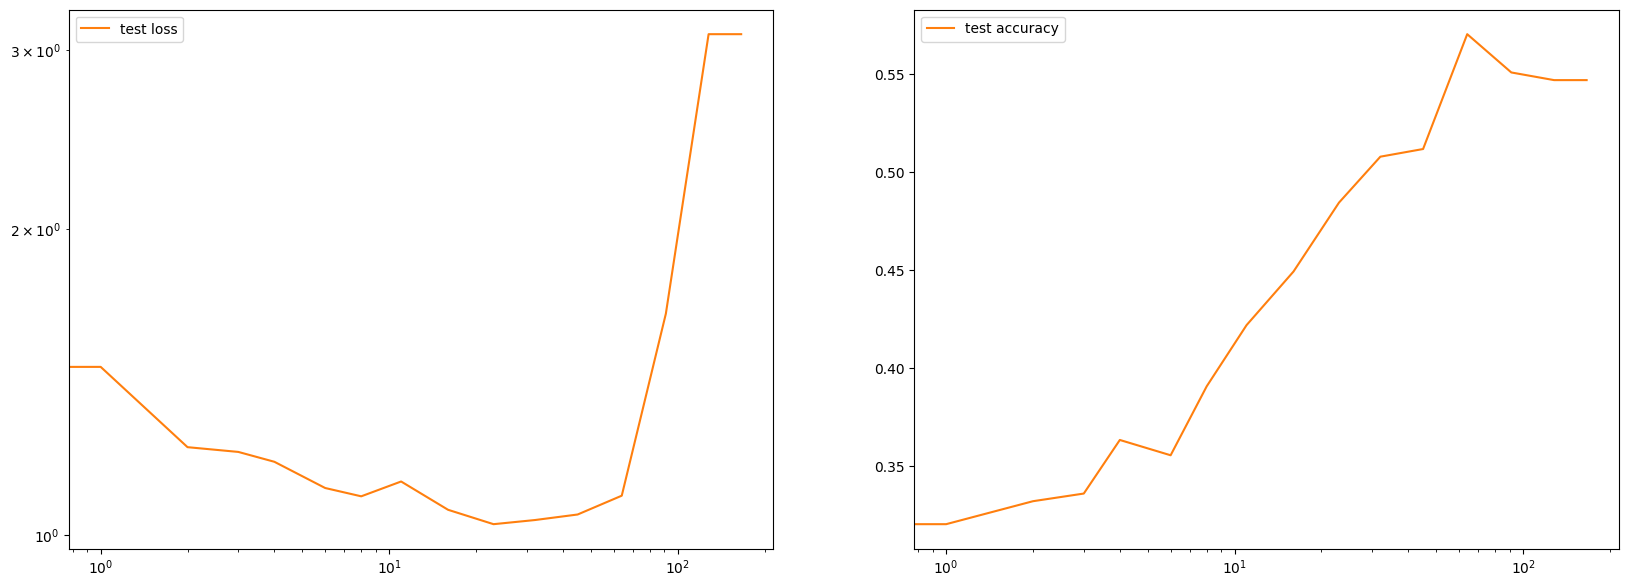

In [ ]:
import math

fig, ax = plt.subplots(1, 2, figsize=(20,7))

ax[0].plot([d['t'] for d in dynamics], [d['testloss'] for d in dynamics], f'C1', label='test loss')
ax[1].plot([d['t'] for d in dynamics], [d['testacc'] for d in dynamics], f'C1', label='test accuracy')

if config.measure_train:
    ax[0].plot([d['t'] for d in dynamics], [d['trainloss'] for d in dynamics], f'C0', label='training loss')
    ax[1].plot([d['t'] for d in dynamics], [d['trainacc'] for d in dynamics], f'C0', label='training accuracy')


# ax[1].plot([d['t'] for d in dynamics], [d['displacement'][2][0] for d in dynamics], f'C2', label='2nd, left')
# ax[1].plot([d['t'] for d in dynamics], [d['displacement'][2][1] for d in dynamics], f'C3', label='2nd, right')


L = config.num_layers
v = config.num_features
m = config.num_synonyms
s = config.tuple_size


ax[0].legend()
ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].legend()
ax[1].set_xscale('log')

In [ ]:
# Quick SAE config presets (run this before SAE training cell)

# switch between: 'debug' (fast) or 'full' (slower, better quality)
sae_mode = 'full'

if sae_mode == 'debug':
    config.sae_layers = '2'          # last layer only for quick checks
    config.sae_steps = 64
    config.sae_latent_dim = 256
    config.sae_lambda_l1 = 5
    config.sae_lr = 1e-3
    config.sae_batch_limit = 4096
    config.sae_print_freq = 16
elif sae_mode == 'full':
    config.sae_layers = 'all'        # train SAE on all transformer blocks
    config.sae_steps = 512
    config.sae_latent_dim = None     # defaults to 4 * embedding_dim in training cell
    config.sae_lambda_l1 = 3
    config.sae_lr = 1e-3
    config.sae_batch_limit = 0       # use all tokens per batch
    config.sae_print_freq = 64
else:
    raise ValueError("sae_mode must be 'debug' or 'full'")

print('SAE config:')
print(f"  mode={sae_mode}")
print(f"  layers={config.sae_layers}")
print(f"  steps={config.sae_steps}")
print(f"  latent_dim={config.sae_latent_dim}")
print(f"  lambda_l1={config.sae_lambda_l1}")
print(f"  lr={config.sae_lr}")
print(f"  batch_limit={config.sae_batch_limit}")
print(f"  print_freq={config.sae_print_freq}")

SAE config:
  mode=full
  layers=all
  steps=512
  latent_dim=None
  lambda_l1=3
  lr=0.001
  batch_limit=0
  print_freq=64


In [ ]:
# Train SAE directly in notebook (post-hoc on frozen ClassificationTransformer)
import copy

# default SAE config values if not present in notebook config
config.sae_layers = getattr(config, 'sae_layers', 'all')
config.sae_latent_dim = getattr(config, 'sae_latent_dim', None)
config.sae_lambda_l1 = getattr(config, 'sae_lambda_l1', 1e-3)
config.sae_lr = getattr(config, 'sae_lr', 1e-3)
config.sae_steps = getattr(config, 'sae_steps', 512)
config.sae_batch_limit = getattr(config, 'sae_batch_limit', 0)
config.sae_print_freq = getattr(config, 'sae_print_freq', 128)


def parse_sae_layers_nb(sae_layers, num_layers):
    if sae_layers is None or str(sae_layers).lower() == 'all':
        return list(range(num_layers))
    layers = [int(layer.strip()) for layer in str(sae_layers).split(',') if layer.strip()]
    assert len(layers) > 0, 'sae_layers must contain at least one valid layer index'
    for layer in layers:
        assert 0 <= layer < num_layers, f'sae layer {layer} out of range [0, {num_layers-1}]'
    return sorted(set(layers))


def train_sae_posthoc_nb(model, train_loader, config):
    assert config.model == 'transformer_class', 'Notebook SAE currently supports transformer_class only'
    assert config.input_format == 'long', 'Notebook SAE requires input_format="long"'

    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    layer_ids = parse_sae_layers_nb(config.sae_layers, model.num_layers)
    latent_dim = config.sae_latent_dim if config.sae_latent_dim is not None else 4 * model.embedding_dim
    batch_limit = config.sae_batch_limit if config.sae_batch_limit > 0 else None
    print_freq = max(int(config.sae_print_freq), 1)

    sae_state = {}
    sae_metrics = {}

    for layer_id in layer_ids:
        sae = models.SparseAutoencoder(model.embedding_dim, latent_dim).to(config.device)
        sae_opt = torch.optim.AdamW(sae.parameters(), lr=config.sae_lr, weight_decay=0.0)

        activation_buffer = []

        def save_activation(_module, _inputs, output):
            activation_buffer.append(output.detach())

        hook = model.blocks[layer_id].register_forward_hook(save_activation)

        step = 0
        running_total = 0.0
        running_recon = 0.0
        running_sparse = 0.0
        last_z = None

        while step < int(config.sae_steps):
            for x_batch, _ in train_loader:
                with torch.no_grad():
                    _ = model(x_batch.to(config.device))

                if not activation_buffer:
                    continue

                activation = activation_buffer.pop(0).reshape(-1, model.embedding_dim)

                if batch_limit is not None and activation.size(0) > batch_limit:
                    idx = torch.randperm(activation.size(0), device=activation.device)[:batch_limit]
                    activation = activation[idx]

                total_loss, recon_loss, sparse_loss = sae.loss(activation, lambda_l1=config.sae_lambda_l1)

                sae_opt.zero_grad()
                total_loss.backward()
                sae_opt.step()

                running_total += total_loss.item()
                running_recon += recon_loss.item()
                running_sparse += sparse_loss.item()

                with torch.no_grad():
                    _, last_z = sae(activation)

                step += 1
                if step % print_freq == 0 or step == int(config.sae_steps):
                    print(
                        f'sae layer {layer_id} step {step}/{int(config.sae_steps)} '
                        f'total={running_total/step:.6f} recon={running_recon/step:.6f} sparse={running_sparse/step:.6f}'
                    )

                if step >= int(config.sae_steps):
                    break

        hook.remove()

        stats = sae.activation_stats(last_z) if last_z is not None else {'active_fraction': 0.0, 'dead_features': latent_dim}
        sae_state[layer_id] = copy.deepcopy(sae.state_dict())
        sae_metrics[layer_id] = {
            'total_loss': running_total / max(step, 1),
            'recon_loss': running_recon / max(step, 1),
            'sparse_loss': running_sparse / max(step, 1),
            'active_fraction': stats['active_fraction'],
            'dead_features': stats['dead_features'],
            'steps': step,
            'latent_dim': latent_dim,
        }

    return sae_state, sae_metrics, layer_ids


sae_state, sae_metrics, sae_layers = train_sae_posthoc_nb(model, train_loader, config)
sae_ckpt_out = f"{config.outname}_sae.pt"

safe_config = {
    'model': config.model,
    'input_format': config.input_format,
    'num_layers': config.num_layers,
    'embedding_dim': config.embedding_dim,
    'sae_layers': config.sae_layers,
    'sae_latent_dim': config.sae_latent_dim,
    'sae_lambda_l1': config.sae_lambda_l1,
    'sae_lr': config.sae_lr,
    'sae_steps': int(config.sae_steps),
    'sae_batch_limit': int(config.sae_batch_limit),
}

torch.save(
    {
        'config': safe_config,
        'sae_layers': sae_layers,
        'sae_state': sae_state,
        'sae_metrics': sae_metrics,
    },
    sae_ckpt_out,
)
print(f"Saved SAE checkpoint: {sae_ckpt_out}")

sae layer 0 step 64/512 total=0.614024 recon=0.318653 sparse=0.098457
sae layer 0 step 128/512 total=0.406117 recon=0.198225 sparse=0.069297
sae layer 0 step 192/512 total=0.315158 recon=0.148928 sparse=0.055410
sae layer 0 step 256/512 total=0.262883 recon=0.121480 sparse=0.047134
sae layer 0 step 320/512 total=0.228530 recon=0.103767 sparse=0.041588
sae layer 0 step 384/512 total=0.203997 recon=0.091283 sparse=0.037571
sae layer 0 step 448/512 total=0.185451 recon=0.081944 sparse=0.034502
sae layer 0 step 512/512 total=0.170880 recon=0.074676 sparse=0.032068
sae layer 1 step 64/512 total=0.982895 recon=0.596477 sparse=0.128806
sae layer 1 step 128/512 total=0.676717 recon=0.393576 sparse=0.094380
sae layer 1 step 192/512 total=0.539700 recon=0.305807 sparse=0.077964
sae layer 1 step 256/512 total=0.459426 recon=0.255601 sparse=0.067942
sae layer 1 step 320/512 total=0.405849 recon=0.222588 sparse=0.061087
sae layer 1 step 384/512 total=0.367091 recon=0.199005 sparse=0.056029
sae laye